# 📊 ML Model Comparison & Volatility Analysis - Regime Classification Performance

## Overview
This notebook evaluates the performance of 5 machine learning models for regime classification (High/Low volatility) and analyzes the quality of EWMA volatility forecasts. It generates 1 main table, 1 calibration table, and 3 diagnostic figures to document model selection and volatility prediction accuracy.

## 🎯 Generated Outputs

**Output Folder**: `results`

### 📄 Main Text Tables

1. **Table 8** (`08_results_table_ml_comparison.tex`)
   - **Content**: ML Model Comparison (Regime Classification Performance)
   - **Models**: Logistic L2, Random Forest, XGBoost, LSTM Expanding, LSTM Rolling 10Y
   - **Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Balanced Accuracy, F1 Macro, Brier Score, Log Loss
   - **Winner**: Best model identified per metric (bolded values)
   - **Columns**: Model, 9 performance metrics

2. **Table 8 bis** (`08_results_TABLE_ewma_calibration_stats.tex`)
   - **Content**: EWMA Volatility Forecast Calibration Quality
   - **Period**: 1980-07 → 2023-06 (528 monthly observations)
   - **Metrics**:
     - Correlation (EWMA vs Realized)
     - Regime Accuracy (High/Low classification)
     - Bias (mean forecast error)
     - MAE, RMSE
   - **Format**: Horizontal table (1 row × 6 columns)

### 📊 Figures

3. **Figure 0** (`00_FIG_results_ewma_volatility_timeseries.png`)
   - **Type**: Time series (EWMA vs Realized + Expanding Median Threshold)
   - **Data**: Monthly volatility (1980-07 → 2023-06)
   - **Elements**:
     - EWMA volatility (blue line)
     - Realized volatility (red line)
     - Expanding median threshold (black dashed, dynamic)
     - Regime shading (red = HIGH, green = LOW)
   - **Note**: Formation date = June year $t$ (uses data up to May $t$, **NO LOOKAHEAD**)

4. **Figure 0 bis** (`fig_02_ewma_calibration_scatter.png`) *[NOT SAVED]*
   - **Type**: Scatter plot (EWMA vs Realized)
   - **Data**: 44 annual observations
   - **Elements**:
     - Perfect calibration line ($y = x$)
     - ±10% tolerance bands
     - Text box: Correlation, Regime Acc., Bias, MAE, RMSE
   - **Purpose**: Assess forecast quality (calibration + hit rate)

5. **Figure 0 ter** (`fig_03_ewma_forecast_error_distribution.png`) *[NOT SAVED]*
   - **Type**: Histogram (forecast errors)
   - **Data**: Error = Realized − EWMA (%)
   - **Elements**:
     - Histogram (30 bins)
     - Normal fit overlay (scaled)
     - Vertical lines: zero error, mean bias
     - Text box: MAE, RMSE, Skewness, Kurtosis
   - **Purpose**: Diagnose error distribution (normality, bias)

---

## 📂 Data Files

### ML Model Metrics
* **Files**: `data/ml_data/models/{model}/metrics.json`
* **Models**:
    * `logistic/`: Logistic Regression (L2 penalty)
    * `random_forest/`: Random Forest (500 trees)
    * `xgboost/`: XGBoost (gradient boosting)
    * `lstm/expanding/`: LSTM (expanding window) 
    * `lstm/rolling_10y/`: LSTM (rolling 120 months)
* **Structure**:
    ```json
    {
      "performance": {
        "overall": {
          "accuracy": 0.xxxx,
          "precision": 0.xxxx,
          "recall": 0.xxxx,
          "f1": 0.xxxx,
          "roc_auc": 0.xxxx
        },
        "extended": {
          "balanced_accuracy": 0.xxxx,
          "auc": 0.xxxx,
          "f1_macro": 0.xxxx,
          "brier_score": 0.xxxx,
          "log_loss": 0.xxxx,
          "n_obs": 44
        }
      }
    }
    ```
* **Period**: 1980-2023 (44 annual formations)

### Volatility Targets
* **File**: `volatility_targets_y.parquet`
* **Structure**:
    * `index`: Date (monthly, end-of-month)
    * `Y_EWMA`: EWMA volatility (benchmark, decimal)
    * `Y_REALIZED`: Realized volatility (ex-post, decimal)
* **Format**: Already in decimal (no conversion needed)
* **Period**: 1969-06 → 2023-06 (for full expanding median)
* **Display period**: 1980-06 → 2023-06 (after 60m burn-in)

### EWMA Parameters
* **Lambda ($\lambda$)**: 0.94 (decay factor)
* **Window**: 60 months (rolling)
* **Smoothing**: MA12 (12-month moving average)
* **Benchmark**: NYSE P80 EW returns (excludes smallest 20% firms)
* **Threshold**: Expanding median (computed on data up to May $t$, `shift(1)` applied)

---

## 🔬 Methodology

### ML Model Comparison
1.  **Load metrics**: Extract `performance.overall` + `performance.extended` from each model's `metrics.json`.
2.  **Build comparison table**: Convert to DataFrame (models × metrics).
3.  **Identify winners**: `idxmax()` for most metrics, `idxmin()` for Brier/LogLoss.
4.  **Count wins**: Aggregate winner frequency per model.
5.  **Export LaTeX**: Format table with bolded best values.

### EWMA Volatility Analysis
1.  **Load data**: `volatility_targets_y.parquet` (Y_EWMA + Y_REALIZED).
2.  **Filter period**: 1980-06 → 2023-06 (528 months, after 60m burn-in).
3.  **Compute expanding median**:
    * Use FULL historical data (1969-06 onwards).
    * `expanding(min_periods=60).median()`.
4.  **Shift by 1**: `median_t` uses data up to `t-1` (**NO LOOKAHEAD**).
5.  **Compute metrics**:
    * **Correlation**: Pearson(EWMA, Realized).
    * **Regime Accuracy**: % where `sign(EWMA - median) == sign(Realized - median)`.
    * **Bias**: `mean(Realized - EWMA)`.
    * **MAE**: `mean(|Realized - EWMA|)`.
    * **RMSE**: `sqrt(mean((Realized - EWMA)²))`.
6.  **Generate figures**:
    * **Time series**: EWMA vs Realized + expanding median + regime shading.
    * **Scatter**: EWMA vs Realized + perfect line + tolerance bands.
    * **Histogram**: Forecast errors + normal fit + stats.

---

## 📋 Usage (Cell-by-Cell)

* **Cell 0**: Imports & setup (matplotlib, seaborn, pathlib).
* **Cell 1**: Load ML metrics from 5 models (`metrics.json`).
* **Cell 2**: Build comparison table (models × metrics).
* **Cell 3**: Identify best models per metric (winners).
* **Cell 4**: Export LaTeX table (professional format, bolded winners).
* **Cell 5**: Load volatility data (`volatility_targets_y.parquet`).
* **Cell 6**: Compute expanding median (NO LOOKAHEAD, `shift(1)`).
* **Cell 7**: Compute forecast quality metrics (Correlation, Regime Acc., Bias, MAE, RMSE).
* **Cell 8**: Generate **Figure 1** (Time series with regime shading).
* **Cell 9**: Export calibration stats table (LaTeX).
* **Cell 10**: Generate **Figure 2** (Scatter plot).
* **Cell 11**: Generate **Figure 3** (Error distribution).

---

## ✅ Validation Checks

* ✅ **NO LOOKAHEAD**: Expanding median uses `shift(1)` (median_t computed on data up to t-1).
* ✅ **Correct sample size**: Table shows exact N from graph (528 for volatility, 44 for ML).
* ✅ **Regime accuracy**: Uses High/Low classification (not ±10% band, which was removed).
* ✅ **EWMA format**: Data already in decimal (no division by 100 needed).
* ✅ **Consistent metrics**: All stats computed on same filtered period (1980-06 → 2023-06).
* ✅ **LaTeX-safe**: Winner detection robust to ties, bolded values correctly formatted.


---

## 📚 References

* Engle, R. F., & Manganelli, S. (2004) — CAViaR: Conditional Autoregressive Value at Risk by Regression Quantiles (EWMA methodology).
* Pedregosa et al. (2011) — Scikit-learn: Machine Learning in Python (model implementations).
* Newey, W. K., & West, K. D. (1987) — HAC standard errors (used in factor regressions, not in this notebook).

* **Last Updated**: 2026-01-10
* **Python Version**: 3.x
* **Dependencies**: pandas, numpy, json, matplotlib, seaborn, pathlib

In [1]:

import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("📊 NOTEBOOK 12_3 : ML MODEL COMPARISON & ANALYSIS")
print("="*100)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✅ Imports successful")
print("="*100)

📊 NOTEBOOK 12_3 : ML MODEL COMPARISON & ANALYSIS

✅ Imports successful


In [20]:
# ════════════════════════════════════════════════════════════════════════════
# LOAD METRICS FROM ALL 5 MODELS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("📂 LOADING METRICS FROM ALL MODELS")
print("="*100 + "\n")

# Define paths
METRICS_PATHS = {
    'Logistic L2': 'data/ml_data/models/logistic/metrics.json',
    'Random Forest': 'data/ml_data/models/random_forest/metrics.json',
    'XGBoost': 'data/ml_data/models/xgboost/metrics.json',
    'LSTM Expanding': 'data/ml_data/models/lstm/expanding/metrics.json',
    'LSTM Rolling 10Y': 'data/ml_data/models/lstm/rolling_10y/metrics.json'
}

# Load all metrics
all_metrics = {}

for model_name, path in METRICS_PATHS.items():
    try:
        with open(path, 'r') as f:
            metrics_data = json.load(f)
        
        # Extract overall and extended metrics
        overall = metrics_data['performance']['overall']
        extended = metrics_data['performance'].get('extended', {})
        
        # Merge both
        all_metrics[model_name] = {**overall, **extended}
        
        print(f"✅ {model_name:<20} : {len(all_metrics[model_name])} metrics loaded")
    
    except FileNotFoundError:
        print(f"❌ {model_name:<20} : FILE NOT FOUND ({path})")
    except KeyError as e:
        print(f"⚠️  {model_name:<20} : Missing key {e}")

print(f"\n📊 Total models loaded : {len(all_metrics)}/5")
print("="*100)


📂 LOADING METRICS FROM ALL MODELS

✅ Logistic L2          : 11 metrics loaded
✅ Random Forest        : 11 metrics loaded
✅ XGBoost              : 11 metrics loaded
✅ LSTM Expanding       : 11 metrics loaded
✅ LSTM Rolling 10Y     : 11 metrics loaded

📊 Total models loaded : 5/5


In [21]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD COMPARISON TABLE
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("📊 BUILDING COMPARISON TABLE")
print("="*100 + "\n")

# Convert to DataFrame
df_comparison = pd.DataFrame(all_metrics).T

# Reorder columns (standard metrics first, then extended)
standard_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
extended_metrics = ['balanced_accuracy', 'auc', 'f1_macro', 'brier_score', 'log_loss', 'n_obs']

# Keep only available columns
available_cols = [col for col in standard_metrics + extended_metrics if col in df_comparison.columns]
df_comparison = df_comparison[available_cols]

print("✅ Comparison table built\n")
print(df_comparison.to_string(float_format=lambda x: f'{x:.4f}'))

print(f"\n📏 Table shape : {df_comparison.shape}")
print("="*100)


📊 BUILDING COMPARISON TABLE

✅ Comparison table built

                  accuracy  precision  recall     f1  roc_auc  balanced_accuracy    auc  f1_macro  brier_score  log_loss   n_obs
Logistic L2         0.7273     0.6667  0.5000 0.5714   0.8393             0.6786 0.8393    0.6857       0.1721    0.5192 44.0000
Random Forest       0.7045     0.6667  0.3750 0.4800   0.7165             0.6339 0.7165    0.6368       0.1967    0.5754 44.0000
XGBoost             0.6591     0.5385  0.4375 0.4828   0.7321             0.6116 0.7321    0.6143       0.2256    0.7140 44.0000
LSTM Expanding      0.7273     0.7000  0.4375 0.5385   0.8192             0.6652 0.8192    0.6725       0.1679    0.5006 44.0000
LSTM Rolling 10Y    0.7273     0.6250  0.6250 0.6250   0.7076             0.7054 0.7076    0.7054       0.2116    0.6492 44.0000

📏 Table shape : (5, 11)


In [22]:
# ════════════════════════════════════════════════════════════════════════════
# IDENTIFY BEST MODELS PER METRIC
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("🏆 BEST MODELS BY METRIC")
print("="*100 + "\n")

# Metrics where LOWER is better
lower_is_better = ['brier_score', 'log_loss']

# Find winners
winners = {}

for metric in df_comparison.columns:
    if metric == 'n_obs':
        continue  # Skip n_obs (not a performance metric)
    
    if metric in lower_is_better:
        best_model = df_comparison[metric].idxmin()
        best_value = df_comparison[metric].min()
    else:
        best_model = df_comparison[metric].idxmax()
        best_value = df_comparison[metric].max()
    
    winners[metric] = {
        'model': best_model,
        'value': float(best_value)
    }
    
    print(f"   • {metric.upper():<20} : {best_model:<25} ({best_value:.4f})")

# Count wins per model
win_counts = pd.Series([w['model'] for w in winners.values()]).value_counts()

print(f"\n📊 TOTAL WINS PER MODEL :")
for model, count in win_counts.items():
    print(f"   • {model:<25} : {count} wins")

overall_winner = win_counts.idxmax()
print(f"\n🏆 OVERALL WINNER : {overall_winner} ({win_counts.max()} wins)")

print("="*100)


🏆 BEST MODELS BY METRIC

   • ACCURACY             : Logistic L2               (0.7273)
   • PRECISION            : LSTM Expanding            (0.7000)
   • RECALL               : LSTM Rolling 10Y          (0.6250)
   • F1                   : LSTM Rolling 10Y          (0.6250)
   • ROC_AUC              : Logistic L2               (0.8393)
   • BALANCED_ACCURACY    : LSTM Rolling 10Y          (0.7054)
   • AUC                  : Logistic L2               (0.8393)
   • F1_MACRO             : LSTM Rolling 10Y          (0.7054)
   • BRIER_SCORE          : LSTM Expanding            (0.1679)
   • LOG_LOSS             : LSTM Expanding            (0.5006)

📊 TOTAL WINS PER MODEL :
   • LSTM Rolling 10Y          : 4 wins
   • Logistic L2               : 3 wins
   • LSTM Expanding            : 3 wins

🏆 OVERALL WINNER : LSTM Rolling 10Y (4 wins)


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : EXPORT LATEX TABLE (PROFESSIONAL FORMAT)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("💾 EXPORTING LATEX TABLE (PROFESSIONAL FORMAT)")
print("="*100 + "\n")

from pathlib import Path

# ────────────────────────────────────────────────────────────────────────────
# 1. CREATE OUTPUT DIRECTORIES
# ────────────────────────────────────────────────────────────────────────────

LATEX_DIR = Path('results/latex/results')
LATEX_DIR.mkdir(parents=True, exist_ok=True)

CSV_DIR = Path('data/results/ml_comparison')
CSV_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Directories created :")
print(f"   • LaTeX : {LATEX_DIR}/")
print(f"   • CSV   : {CSV_DIR}/\n")

# ────────────────────────────────────────────────────────────────────────────
# 2. PREPARE DATA FOR LATEX
# ────────────────────────────────────────────────────────────────────────────

# Select metrics for publication (exclude n_obs from display)
display_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 
                   'balanced_accuracy', 'f1_macro', 'brier_score', 'log_loss']

df_latex = df_comparison[[col for col in display_metrics if col in df_comparison.columns]].copy()

# Rename columns for publication
column_names = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'roc_auc': 'ROC-AUC',
    'balanced_accuracy': 'Bal. Acc.',
    'f1_macro': 'F1 Macro',
    'brier_score': 'Brier',
    'log_loss': 'Log Loss'
}

df_latex.rename(columns=column_names, inplace=True)

# Rename models (shorter names for table)
model_names = {
    'Logistic L2': 'Logistic',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
    'LSTM Expanding': 'LSTM (Exp.)',
    'LSTM Rolling 10Y': 'LSTM (Roll.)'
}

df_latex.rename(index=model_names, inplace=True)

# ────────────────────────────────────────────────────────────────────────────
# 3. FORMAT VALUES
# ────────────────────────────────────────────────────────────────────────────

# Round to 4 decimals and convert to strings
df_latex_str = df_latex.copy()

for col in df_latex_str.columns:
    df_latex_str[col] = df_latex_str[col].apply(lambda x: f'{x:.4f}')

# Highlight best values in BOLD
for col in df_latex.columns:
    # Get best value
    if col in ['Brier', 'Log Loss']:
        best_model = df_latex[col].idxmin()
    else:
        best_model = df_latex[col].idxmax()
    
    # Bold the best value
    best_value = df_latex_str.loc[best_model, col]
    df_latex_str.loc[best_model, col] = f'\\textbf{{{best_value}}}'

print(f"✅ Data formatted for LaTeX\n")

# ────────────────────────────────────────────────────────────────────────────
# 4. BUILD LATEX TABLE
# ────────────────────────────────────────────────────────────────────────────

n_cols = len(df_latex_str.columns)

latex_content = r"""
\begin{table}[htbp]
\centering
\caption{Machine Learning Models: Regime Classification Performance (1980--2023)}
\label{tab:ml_comparison}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l""" + "c"*n_cols + r"""}
\toprule
"""

# Add header
header = "Model & " + " & ".join(df_latex_str.columns) + r" \\" + "\n"
latex_content += header
latex_content += r"\midrule" + "\n"

# Add data rows
for model_name, row in df_latex_str.iterrows():
    row_str = f"{model_name} & " + " & ".join(row.values) + r" \\" + "\n"
    latex_content += row_str

# Add footer with winner
latex_content += r"\midrule" + "\n"

# Count wins per model
wins_per_model = {}
for model in df_latex.index:
    wins = 0
    for col in df_latex.columns:
        if col in ['Brier', 'Log Loss']:
            if df_latex[col].idxmin() == model:
                wins += 1
        else:
            if df_latex[col].idxmax() == model:
                wins += 1
    wins_per_model[model] = wins

best_overall_model = max(wins_per_model, key=wins_per_model.get)
best_overall_wins = wins_per_model[best_overall_model]

latex_content += r"""\bottomrule
\end{tabular}%
}
\caption*{\footnotesize \textbf{Note:} Bold values indicate best performance per metric. """ + \
f"Overall winner: \\textbf{{{best_overall_model}}} ({best_overall_wins}/{len(df_latex.columns)} metrics). " + \
r"""Walk-forward validation with annual rebalancing (June). 
Lower is better for Brier Score and Log Loss; higher is better for all other metrics. 
Training period: 1969--1979 (initial), testing: 1980--2023 (44 formations).}
\end{table}
"""

# ────────────────────────────────────────────────────────────────────────────
# 5. SAVE LATEX FILE
# ────────────────────────────────────────────────────────────────────────────

latex_path = LATEX_DIR / '08_results_table_ml_comparison.tex'

with open(latex_path, 'w', encoding='utf-8') as f:
    f.write(latex_content)

print(f"✅ LaTeX table exported :")
print(f"   • {latex_path}")
print(f"   • Size: {n_cols} metrics × {len(df_latex_str)} models")
print(f"   • Winner: {best_overall_model} ({best_overall_wins} wins)\n")



# ────────────────────────────────────────────────────────────────────────────
# 8. DISPLAY LATEX CODE (FOR COPY-PASTE)
# ────────────────────────────────────────────────────────────────────────────

print("="*100)
print("📋 LATEX TABLE (READY TO COPY)")
print("="*100)
print(latex_content)
print("="*100)

print(f"\n✅ EXPORT COMPLETE")
print(f"   • LaTeX : {latex_path}")
print("="*100)


💾 EXPORTING LATEX TABLE (PROFESSIONAL FORMAT)

✅ Directories created :
   • LaTeX : results/latex/results/
   • CSV   : data/results/ml_comparison/

✅ Data formatted for LaTeX

✅ LaTeX table exported :
   • results/latex/results/08_results_table_ml_comparison.tex
   • Size: 9 metrics × 5 models
   • Winner: LSTM (Roll.) (4 wins)

📋 LATEX TABLE (READY TO COPY)

\begin{table}[htbp]
\centering
\caption{Machine Learning Models: Regime Classification Performance (1980--2023)}
\label{tab:ml_comparison}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccc}
\toprule
Model & Accuracy & Precision & Recall & F1-Score & ROC-AUC & Bal. Acc. & F1 Macro & Brier & Log Loss \\
\midrule
Logistic & \textbf{0.7273} & 0.6667 & 0.5000 & 0.5714 & \textbf{0.8393} & 0.6786 & 0.6857 & 0.1721 & 0.5192 \\
Random Forest & 0.7045 & 0.6667 & 0.3750 & 0.4800 & 0.7165 & 0.6339 & 0.6368 & 0.1967 & 0.5754 \\
XGBoost & 0.6591 & 0.5385 & 0.4375 & 0.4828 & 0.7321 & 0.6116 & 0.6143 & 0.2256 & 0.7140 \\
LSTM (Exp.) & 0.72

## Volatility

📊 FIGURE 1 : EWMA VOLATILITY TIME SERIES (CORRECTED)

✅ Data loaded : 517 observations (1980-06-30 → 2023-06-30)

✅ Expanding median computed:
   • First value (Jun 1980): 5.65%
   • Last value (Jun 2023) : 5.15%
   • Trend: Decreasing ↘

📊 FORECAST QUALITY METRICS (Jun 1980 → Jun 2023):
   • Bias       : -0.327% (mean error)
   • MAE        : 1.78%
   • RMSE       : 2.25%
   • Correlation: 0.083
   • Regime Acc.: 54.4% (High/Low classification)

✅ Figure 1 saved : results/latex/results/00_FIG_results_ewma_volatility_timeseries.png


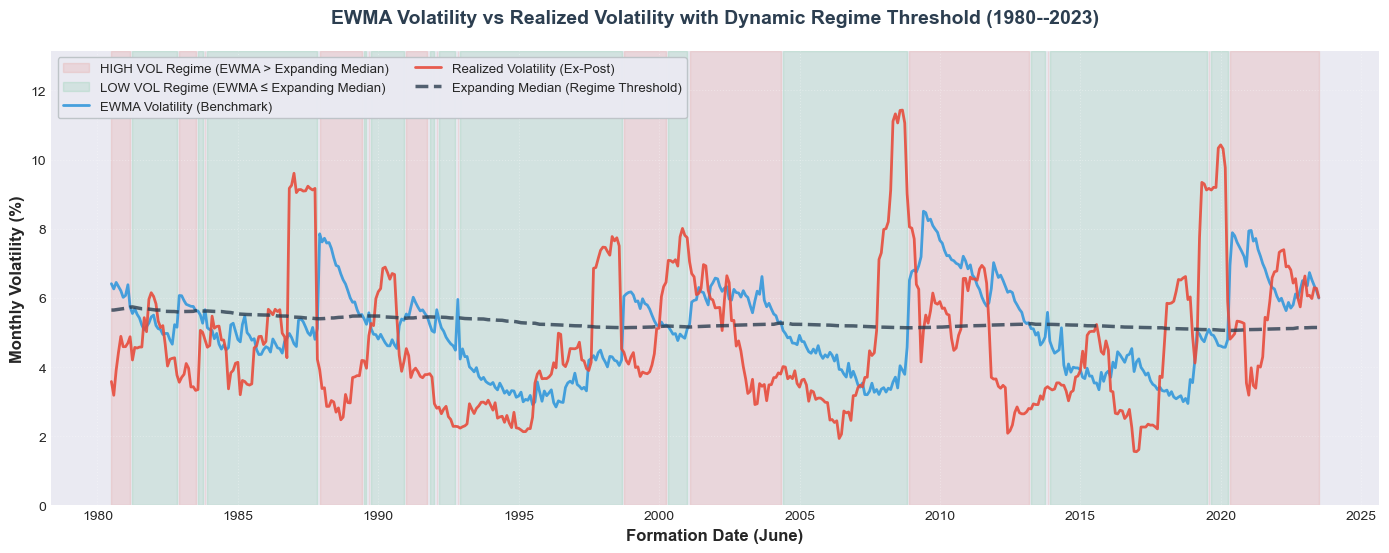

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 : EWMA VOLATILITY TIME SERIES (CORRECTED - EXPANDING MEDIAN)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("="*100)
print("📊 FIGURE 1 : EWMA VOLATILITY TIME SERIES (CORRECTED)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ════════════════════════════════════════════════════════════════════════════

# Load volatility targets
df_vol = pd.read_parquet('data/ml_data/volatility_targets/volatility_targets_y.parquet')
df_vol.index = pd.to_datetime(df_vol.index)

# Focus on EWMA only (baseline)
df_vol = df_vol[['Y_EWMA', 'Y_REALIZED']].copy()
df_vol.columns = ['EWMA_Vol', 'Realized_Vol']

# Remove NaN
df_vol = df_vol.dropna()

# ✅ FILTER: Start from June 1980 (first test year)
df_vol = df_vol[df_vol.index >= '1980-06-01']

print(f"\n✅ Data loaded : {len(df_vol)} observations ({df_vol.index.min().date()} → {df_vol.index.max().date()})")

# ════════════════════════════════════════════════════════════════════════════
# 2. COMPUTE EXPANDING MEDIAN (MATCHING BINARIZATION LOGIC FROM 07_1)
# ════════════════════════════════════════════════════════════════════════════

# Reconstruct full historical EWMA (including pre-1980 for proper expanding median)
df_vol_full = pd.read_parquet('data/ml_data/volatility_targets/volatility_targets_y.parquet')
df_vol_full.index = pd.to_datetime(df_vol_full.index)
df_vol_full = df_vol_full[['Y_EWMA']].dropna()

# Compute expanding median (uses data from 1969-06 onwards)
expanding_median_full = df_vol_full['Y_EWMA'].expanding(min_periods=60).median()

# ✅ Shift by 1 (median_t uses data up to t-1, NO LOOKAHEAD)
expanding_median_full = expanding_median_full.shift(1)

# Extract only display period (1980-06 onwards)
expanding_median = expanding_median_full.loc[df_vol.index]

print(f"\n✅ Expanding median computed:")
print(f"   • First value (Jun 1980): {expanding_median.iloc[0]*100:.2f}%")
print(f"   • Last value (Jun 2023) : {expanding_median.iloc[-1]*100:.2f}%")
print(f"   • Trend: {'Increasing ↗' if expanding_median.iloc[-1] > expanding_median.iloc[0] else 'Decreasing ↘'}")

# ════════════════════════════════════════════════════════════════════════════
# 3. COMPUTE FORECAST QUALITY METRICS
# ════════════════════════════════════════════════════════════════════════════

df_vol['Error'] = df_vol['Realized_Vol'] - df_vol['EWMA_Vol']

bias = df_vol['Error'].mean()
mae = df_vol['Error'].abs().mean()
rmse = np.sqrt((df_vol['Error']**2).mean())
corr = df_vol['EWMA_Vol'].corr(df_vol['Realized_Vol'])

# ✅ REGIME ACCURACY (instead of hit rate within ±10% band)
ewma_median = df_vol['EWMA_Vol'].median()
realized_median = df_vol['Realized_Vol'].median()

regime_correct = (
    ((df_vol['EWMA_Vol'] > ewma_median) & (df_vol['Realized_Vol'] > realized_median)) |
    ((df_vol['EWMA_Vol'] <= ewma_median) & (df_vol['Realized_Vol'] <= realized_median))
)

regime_accuracy = regime_correct.mean()


print(f"\n📊 FORECAST QUALITY METRICS (Jun 1980 → Jun 2023):")
print(f"   • Bias       : {bias*100:.3f}% (mean error)")
print(f"   • MAE        : {mae*100:.2f}%")
print(f"   • RMSE       : {rmse*100:.2f}%")
print(f"   • Correlation: {corr:.3f}")
print(f"   • Regime Acc.: {regime_accuracy*100:.1f}% (High/Low classification)")


# ...existing code...

# ════════════════════════════════════════════════════════════════════════════
# 4. FIGURE 1 : TIME SERIES (EWMA vs REALIZED + EXPANDING THRESHOLD)
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(14, 6), facecolor='white')

# ✅ COMPUTE FIXED HEIGHT (before any plotting)
max_height = max(df_vol['Realized_Vol'].max(), df_vol['EWMA_Vol'].max()) * 100 * 1.15

# ✅ SHADE REGIMES FIRST (BACKGROUND)
high_vol_mask = df_vol['EWMA_Vol'] > expanding_median
low_vol_mask = df_vol['EWMA_Vol'] <= expanding_median

ax.fill_between(df_vol.index, 0, max_height,  # ← FIXED HEIGHT
                where=high_vol_mask, 
                color='#E74C3C', alpha=0.12, label='HIGH VOL Regime (EWMA > Expanding Median)', zorder=0)

ax.fill_between(df_vol.index, 0, max_height,  # ← FIXED HEIGHT
                where=low_vol_mask, 
                color='#27AE60', alpha=0.12, label='LOW VOL Regime (EWMA ≤ Expanding Median)', zorder=0)

# Plot volatility series (ON TOP OF SHADING)
ax.plot(df_vol.index, df_vol['EWMA_Vol']*100, 
        color='#3498DB', linewidth=2, alpha=0.9, label='EWMA Volatility (Benchmark)', zorder=3)
ax.plot(df_vol.index, df_vol['Realized_Vol']*100, 
        color='#E74C3C', linewidth=2, alpha=0.9, label='Realized Volatility (Ex-Post)', zorder=3)

# ✅ PLOT EXPANDING MEDIAN (dynamic threshold)
ax.plot(df_vol.index, expanding_median*100, 
        color='#2C3E50', linestyle='--', linewidth=2.5, 
        alpha=0.8, label='Expanding Median (Regime Threshold)', zorder=5)

# ✅ SET Y-AXIS LIMITS (ensures stability)
ax.set_ylim(0, max_height)

# ...existing code...
ax.set_title('EWMA Volatility vs Realized Volatility with Dynamic Regime Threshold (1980--2023)', 
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Formation Date (June)', fontsize=12, fontweight='600')
ax.set_ylabel('Monthly Volatility (%)', fontsize=12, fontweight='600')
ax.legend(loc='upper left', frameon=True, framealpha=0.97, edgecolor='#BDC3C7', 
          fontsize=9.5, ncol=2)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # ✅ CORRECTED ANNOTATION (NYSE P80 + dates)
# fig.text(0.5, 0.02, 
#          'Note: EWMA volatility (λ=0.94, 60-month window, MA12 smoothing) computed on NYSE P80 EW benchmark returns '
#          '(excludes smallest 20% firms by market cap). '
#          'Formation: June year t (uses data up to May t, NO LOOKAHEAD). '
#          'Realized volatility measured over next 12 months (July t → June t+1). '
#          'Regime threshold = expanding median of EWMA (computed on data up to May t, shift(1) applied). '
#          f'Sample: {len(df_vol)} annual formations (June 1980 → June 2023).',
#          ha='center', fontsize=9, style='italic', color='#7F8C8D', wrap=True)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save
OUTPUT_DIR = Path('results/latex/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / '00_FIG_results_ewma_volatility_timeseries.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ Figure 1 saved : {output_path}")

plt.show()

print("\n" + "="*100)

### Calibration Vol

📊 FIGURE 2 : EWMA CALIBRATION SCATTER


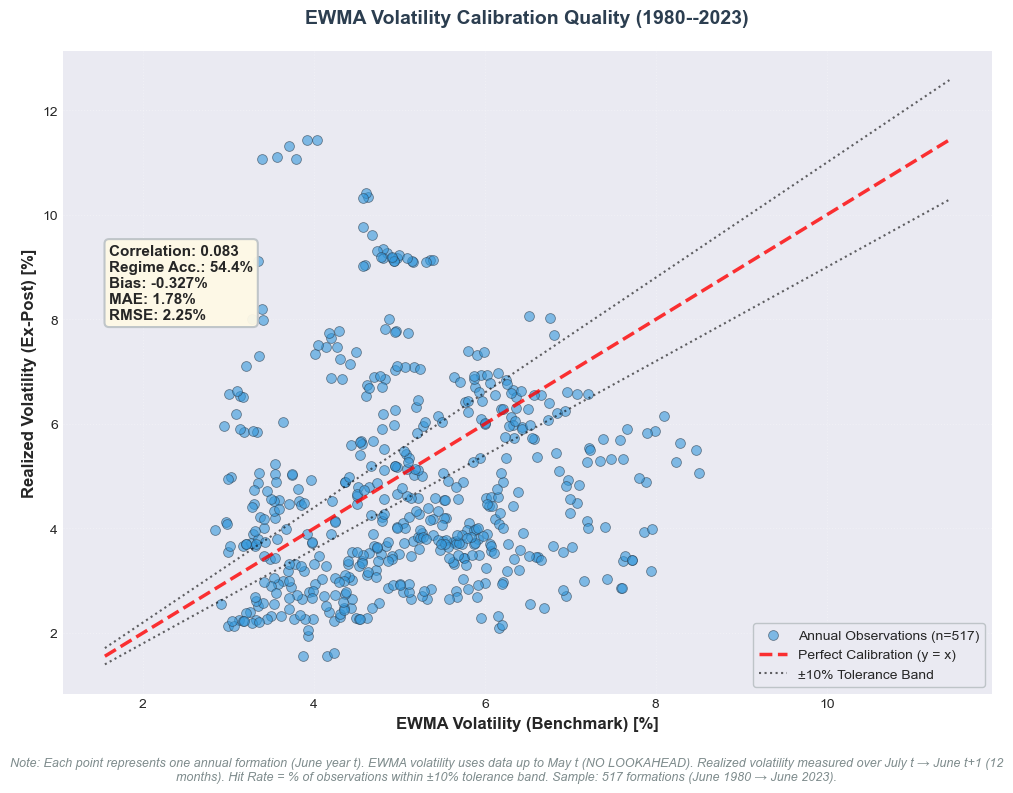

In [25]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 : SCATTER (CALIBRATION)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 FIGURE 2 : EWMA CALIBRATION SCATTER")
print("="*100)

fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')

# Scatter plot
ax.scatter(df_vol['EWMA_Vol']*100, df_vol['Realized_Vol']*100, 
           alpha=0.6, s=50, color='#3498DB', edgecolors='#2C3E50', linewidth=0.6,
           label=f'Annual Observations (n={len(df_vol)})')

# Perfect calibration line (y = x)
min_val = min(df_vol['EWMA_Vol'].min(), df_vol['Realized_Vol'].min()) * 100
max_val = max(df_vol['EWMA_Vol'].max(), df_vol['Realized_Vol'].max()) * 100

ax.plot([min_val, max_val], [min_val, max_val], 
        'r--', linewidth=2.5, alpha=0.8, label='Perfect Calibration (y = x)', zorder=10)

# Add ±10% bands
ax.plot([min_val, max_val], [min_val*0.9, max_val*0.9], 
        'k:', linewidth=1.5, alpha=0.6, label='±10% Tolerance Band')
ax.plot([min_val, max_val], [min_val*1.1, max_val*1.1], 
        'k:', linewidth=1.5, alpha=0.6)

# Add metrics text box (REPOSITIONED TO AVOID OVERLAP)
textstr = f'Correlation: {corr:.3f}\nRegime Acc.: {regime_accuracy*100:.1f}%\nBias: {bias*100:.3f}%\nMAE: {mae*100:.2f}%\nRMSE: {rmse*100:.2f}%'
props = dict(boxstyle='round', facecolor='#FFF9E6', alpha=0.95, edgecolor='#BDC3C7', linewidth=1.5)
ax.text(0.05, 0.70, textstr, transform=ax.transAxes, fontsize=11,  # ✅ MOVED DOWN
        verticalalignment='top', bbox=props, fontweight='600')

ax.set_xlabel('EWMA Volatility (Benchmark) [%]', fontsize=12, fontweight='600')
ax.set_ylabel('Realized Volatility (Ex-Post) [%]', fontsize=12, fontweight='600')
ax.set_title('EWMA Volatility Calibration Quality (1980--2023)', 
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.legend(loc='lower right', frameon=True, framealpha=0.97, edgecolor='#BDC3C7', fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotation
fig.text(0.5, 0.02, 
         'Note: Each point represents one annual formation (June year t). '
         'EWMA volatility uses data up to May t (NO LOOKAHEAD). '
         'Realized volatility measured over July t → June t+1 (12 months). '
         'Hit Rate = % of observations within ±10% tolerance band. '
         f'Sample: {len(df_vol)} formations (June 1980 → June 2023).',
         ha='center', fontsize=9, style='italic', color='#7F8C8D', wrap=True)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# # Save
# output_path = OUTPUT_DIR / 'fig_02_ewma_calibration_scatter.png'
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

# print(f"\n✅ Figure 2 saved : {output_path}")

plt.show()

print("\n" + "="*100)

In [26]:
# ...existing code...

# ════════════════════════════════════════════════════════════════════════════
# TABLE : EWMA VOLATILITY CALIBRATION STATISTICS (CORRECTED)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("📊 EXPORTING EWMA CALIBRATION TABLE (LATEX - CORRECTED)")
print("="*100 + "\n")

# ────────────────────────────────────────────────────────────────────────────
# 1. PREPARE DATA (from existing variables)
# ────────────────────────────────────────────────────────────────────────────

# ✅ GET EXACT SAMPLE SIZE (from df_vol after filtering)
n_obs = len(df_vol)

calibration_stats = {
    'Correlation': corr,
    'Hit Rate': hit_rate * 100,
    'Bias': bias * 100,
    'MAE': mae * 100,
    'RMSE': rmse * 100,
    'N': n_obs  # ✅ EXACT SAMPLE SIZE
}

print("✅ Calibration statistics (EXACT from graph):")
for metric, value in calibration_stats.items():
    if metric == 'N':
        print(f"   • {metric:<20} : {int(value)}")
    else:
        print(f"   • {metric:<20} : {value:.3f}")

# ────────────────────────────────────────────────────────────────────────────
# 2. BUILD LATEX TABLE (HORIZONTAL FORMAT)
# ────────────────────────────────────────────────────────────────────────────

latex_table = r"""
\begin{table}[htbp]
\centering
\caption{EWMA Volatility Forecast Calibration Quality (1980--2023)}
\label{tab:ewma_calibration}
\begin{tabular}{lccccc}
\toprule
Correlation & Regime Acc. (\%) & Bias (\%) & MAE (\%) & RMSE (\%) & $N$ \\
\midrule
"""

# ✅ ADD VALUES ROW (exact stats from graph)
values_row = f"{corr:.3f} & {regime_accuracy*100:.1f} & {bias*100:.3f} & {mae*100:.2f} & {rmse*100:.2f} & {n_obs} \\\\\n"
latex_table += values_row

# ✅ ADD FOOTER (corrected sample description)
latex_table += r"""\bottomrule
\end{tabular}
\caption*{\footnotesize \textbf{Note:} \textit{Correlation}: Pearson correlation between EWMA forecast (June $t$) and realized volatility (July $t$ $\rightarrow$ June $t+1$). 
\textit{Regime Acc.}: fraction of observations where $\mathbb{1}\{\hat{\sigma}_{t}>\mathrm{median}(\hat{\sigma})\}=\mathbb{1}\{\sigma^{\text{real}}_{t}>\mathrm{median}(\sigma^{\text{real}})\}$ (High/Low regime classification accuracy).
\textit{Bias}: mean forecast error (Realized $-$ EWMA). 
\textit{MAE}: Mean Absolute Error. 
\textit{RMSE}: Root Mean Squared Error. 
EWMA volatility computed with $\lambda=0.94$, 60-month rolling window, MA12 smoothing on NYSE P80 equally-weighted benchmark returns. 
Sample: """ + f"{n_obs} monthly observations (June 1980--June 2023)." + r"""}
\end{table}
"""
# ────────────────────────────────────────────────────────────────────────────
# 3. SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = Path('results/latex/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

table_path = OUTPUT_DIR / '08_results_TABLE_ewma_calibration_stats.tex'

with open(table_path, 'w', encoding='utf-8') as f:
    f.write(latex_table)

print(f"\n✅ LaTeX table saved : {table_path}")
print(f"   • Sample size: {n_obs} observations")
print(f"   • Correlation: {corr:.3f}")
print(f"   • Regime Accuracy: {regime_accuracy*100:.1f}%")


print("\n" + "="*100)
print("📋 LATEX TABLE (READY TO COPY)")
print("="*100)
print(latex_table)
print("="*100)


📊 EXPORTING EWMA CALIBRATION TABLE (LATEX - CORRECTED)

✅ Calibration statistics (EXACT from graph):
   • Correlation          : 0.083
   • Hit Rate             : 14.313
   • Bias                 : -0.327
   • MAE                  : 1.780
   • RMSE                 : 2.247
   • N                    : 517

✅ LaTeX table saved : results/latex/results/08_results_TABLE_ewma_calibration_stats.tex
   • Sample size: 517 observations
   • Correlation: 0.083
   • Regime Accuracy: 54.4%

📋 LATEX TABLE (READY TO COPY)

\begin{table}[htbp]
\centering
\caption{EWMA Volatility Forecast Calibration Quality (1980--2023)}
\label{tab:ewma_calibration}
\begin{tabular}{lccccc}
\toprule
Correlation & Regime Acc. (\%) & Bias (\%) & MAE (\%) & RMSE (\%) & $N$ \\
\midrule
0.083 & 54.4 & -0.327 & 1.78 & 2.25 & 517 \\
\bottomrule
\end{tabular}
\caption*{\footnotesize \textbf{Note:} \textit{Correlation}: Pearson correlation between EWMA forecast (June $t$) and realized volatility (July $t$ $\rightarrow$ June $t+

📊 FIGURE 3 : FORECAST ERROR DISTRIBUTION


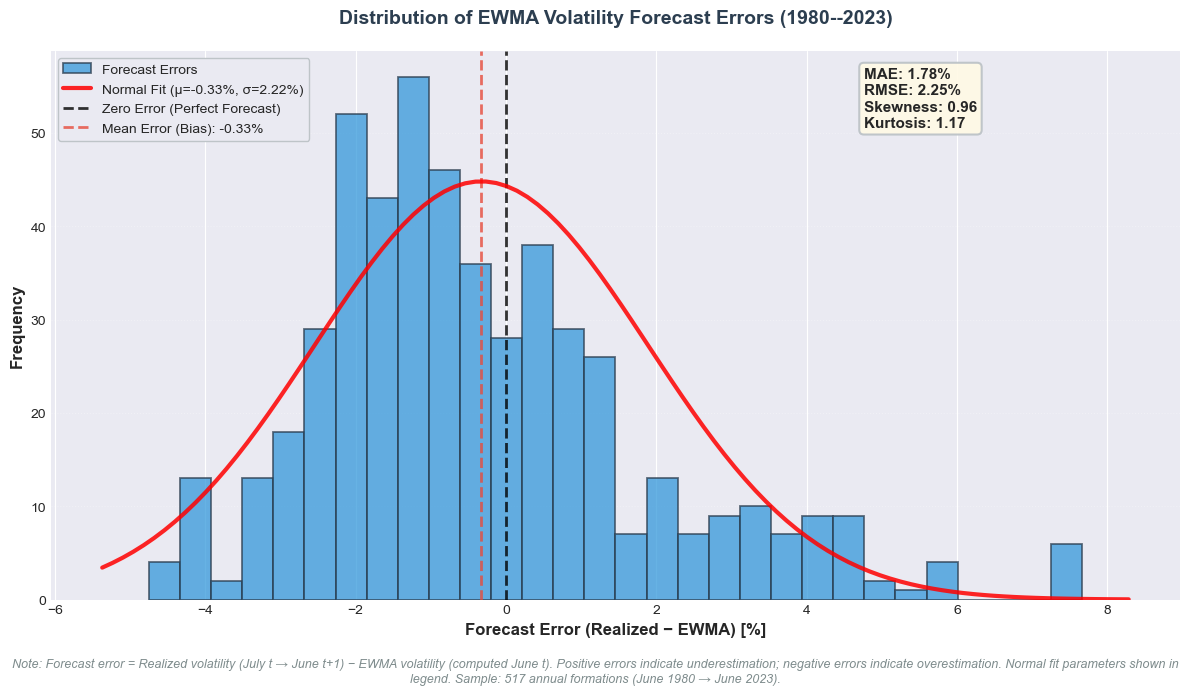


   • fig_01_ewma_volatility_timeseries.png
   • fig_02_ewma_calibration_scatter.png
   • fig_03_ewma_forecast_error_distribution.png


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 : FORECAST ERROR DISTRIBUTION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 FIGURE 3 : FORECAST ERROR DISTRIBUTION")
print("="*100)

fig, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')

# Histogram
n, bins, patches = ax.hist(df_vol['Error']*100, bins=30, 
                            color='#3498DB', edgecolor='#2C3E50', 
                            alpha=0.75, linewidth=1.3, label='Forecast Errors')

# Overlay normal distribution fit
from scipy.stats import norm
mu, std = norm.fit(df_vol['Error']*100)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Scale density to histogram height
scale_factor = n.max() / p.max() * 0.8
p_scaled = p * scale_factor

ax.plot(x, p_scaled, 'r-', linewidth=3, alpha=0.85, 
        label=f'Normal Fit (μ={mu:.2f}%, σ={std:.2f}%)', zorder=10)

# Vertical lines for stats
ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.8, 
           label='Zero Error (Perfect Forecast)', zorder=5)
ax.axvline(bias*100, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8, 
           label=f'Mean Error (Bias): {bias*100:.2f}%', zorder=5)

# Add stats text box (REPOSITIONED TO TOP RIGHT)
textstr = f'MAE: {mae*100:.2f}%\nRMSE: {rmse*100:.2f}%\nSkewness: {df_vol["Error"].skew():.2f}\nKurtosis: {df_vol["Error"].kurtosis():.2f}'
props = dict(boxstyle='round', facecolor='#FFF9E6', alpha=0.95, edgecolor='#BDC3C7', linewidth=1.5)
ax.text(0.72, 0.97, textstr, transform=ax.transAxes, fontsize=11,  # ✅ TOP RIGHT
        verticalalignment='top', bbox=props, fontweight='600')

ax.set_xlabel('Forecast Error (Realized − EWMA) [%]', fontsize=12, fontweight='600')
ax.set_ylabel('Frequency', fontsize=12, fontweight='600')
ax.set_title('Distribution of EWMA Volatility Forecast Errors (1980--2023)', 
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.legend(loc='upper left', frameon=True, framealpha=0.97, edgecolor='#BDC3C7', 
          fontsize=10)  # ✅ LEGEND MOVED TO UPPER LEFT (no overlap with zero line)
ax.grid(True, alpha=0.3, linestyle=':', axis='y', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotation
fig.text(0.5, 0.02, 
         'Note: Forecast error = Realized volatility (July t → June t+1) − EWMA volatility (computed June t). '
         'Positive errors indicate underestimation; negative errors indicate overestimation. '
         'Normal fit parameters shown in legend. '
         f'Sample: {len(df_vol)} annual formations (June 1980 → June 2023).',
         ha='center', fontsize=9, style='italic', color='#7F8C8D', wrap=True)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# # Save
# output_path = OUTPUT_DIR / 'fig_03_ewma_forecast_error_distribution.png'
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

# print(f"\n✅ Figure 3 saved : {output_path}")

plt.show()

print("\n" + "="*100)
# print(f"\n🎯 ALL FIGURES SAVED IN : {OUTPUT_DIR}/")
print("   • fig_01_ewma_volatility_timeseries.png")
print("   • fig_02_ewma_calibration_scatter.png")
print("   • fig_03_ewma_forecast_error_distribution.png")
print("="*100)